In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/Mall_Customers.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Drop CustomerID since it's not a real feature, just an identifier

df = df.drop('CustomerID', axis=1)

print("CustomerID dropped!")
print(f"New shape: {df.shape}")
df.head()

CustomerID dropped!
New shape: (200, 4)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [3]:
# Method 1: Using map  to convert 'Female' to 0 and 'Male' to 1

df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Verify the encoding

print(" Gender encoded successfully!")
print("\nUnique values in Gender after encoding:")

print(df['Gender'].unique())
print("\nValue counts:")
print(df['Gender'].value_counts())
print("\nFirst 5 rows:")
df.head()

 Gender encoded successfully!

Unique values in Gender after encoding:
[1 0]

Value counts:
Gender
0    112
1     88
Name: count, dtype: int64

First 5 rows:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [4]:
# Verify all columns are now numeric

print("Data types after encoding:")
print(df.dtypes)

Data types after encoding:
Gender                    int64
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [5]:
# Separate features for scaling

# We'll scale Age, Income, and Spending Score

# Gender doesn't need scaling (it's already 0/1)

features_to_scale = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Create a copy for scaling
df_scaled = df.copy()

print("Features identified for scaling:")
print(features_to_scale)

Features identified for scaling:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [6]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the selected features
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Data scaled successfully!")

print("\nScaled data (first 5 rows):")
df_scaled.head()

Data scaled successfully!

Scaled data (first 5 rows):


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


In [7]:
# Check the mean and std of scaled features

print("Mean of scaled features:")

print(df_scaled[features_to_scale].mean().round(2))

print("\nStandard deviation of scaled features:")

print(df_scaled[features_to_scale].std().round(2))

Mean of scaled features:
Age                      -0.0
Annual Income (k$)       -0.0
Spending Score (1-100)   -0.0
dtype: float64

Standard deviation of scaled features:
Age                       1.0
Annual Income (k$)        1.0
Spending Score (1-100)    1.0
dtype: float64


In [8]:
# Compare original vs scaled values 

print("="*50)
print("ORIGINAL DATA (first 5 rows):")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("SCALED DATA (first 5 rows):")
print("="*50)
print(df_scaled.head())

ORIGINAL DATA (first 5 rows):
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40

SCALED DATA (first 5 rows):
   Gender       Age  Annual Income (k$)  Spending Score (1-100)
0       1 -1.424569           -1.738999               -0.434801
1       1 -1.281035           -1.738999                1.195704
2       0 -1.352802           -1.700830               -1.715913
3       0 -1.137502           -1.700830                1.040418
4       0 -0.563369           -1.662660               -0.395980


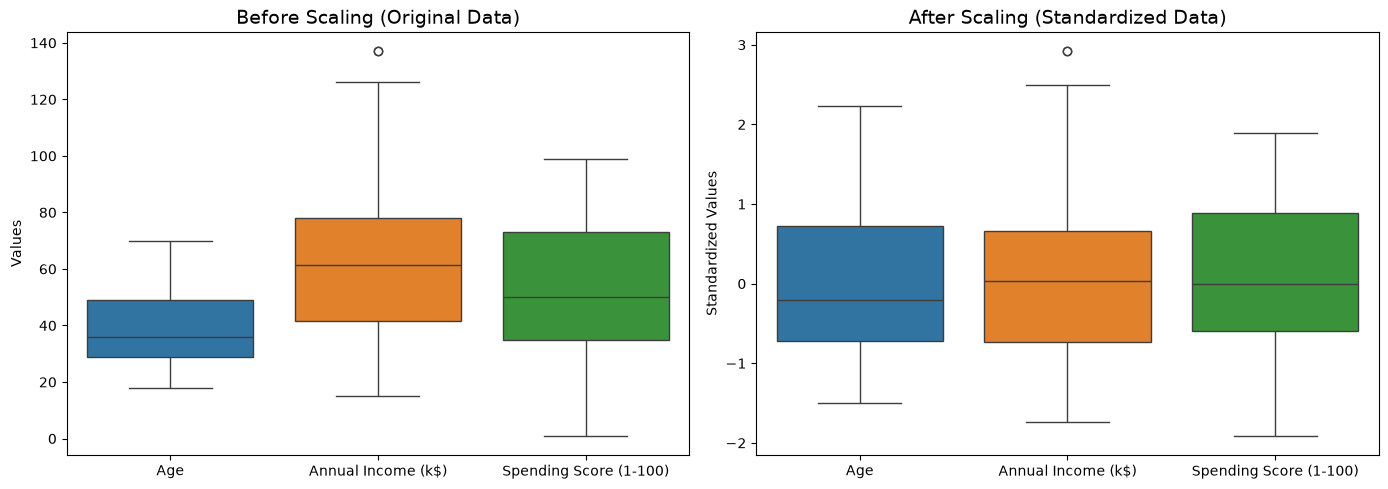

In [10]:
# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
sns.boxplot(data=df[features_to_scale], ax=axes[0])
axes[0].set_title('Before Scaling (Original Data)', fontsize=14)
axes[0].set_ylabel('Values')

# After scaling
sns.boxplot(data=df_scaled[features_to_scale], ax=axes[1])
axes[1].set_title('After Scaling (Standardized Data)', fontsize=14)
axes[1].set_ylabel('Standardized Values')

plt.tight_layout()
plt.savefig('../images/before_after_scaling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Save the scaled data for modeling
df_scaled.to_csv('../data/mall_customers_scaled.csv', index=False)

# Also save the original processed data (we'll need it for interpretation)
df.to_csv('../data/mall_customers_processed.csv', index=False)

print("Scaled data saved to: ../data/mall_customers_scaled.csv")
print(" Processed data saved to: ../data/mall_customers_processed.csv")
print("\nFiles saved successfully!")

Scaled data saved to: ../data/mall_customers_scaled.csv
 Processed data saved to: ../data/mall_customers_processed.csv

Files saved successfully!


In [12]:
import pickle

# Save the scaler for later use (when making predictions on our streamlit app)

with open('../src/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Scaler saved to: ../src/scaler.pkl")

Scaler saved to: ../src/scaler.pkl


In [13]:
print("="*50)
print("FINAL PREPROCESSED DATASET SUMMARY")
print("="*50)
print(f"Total records: {len(df_scaled)}")
print(f"Total features: {len(df_scaled.columns)}")
print(f"Features: {list(df_scaled.columns)}")
print("\nStatistical summary of scaled data:")
print(df_scaled.describe().round(2))

FINAL PREPROCESSED DATASET SUMMARY
Total records: 200
Total features: 4
Features: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Statistical summary of scaled data:
       Gender     Age  Annual Income (k$)  Spending Score (1-100)
count  200.00  200.00              200.00                  200.00
mean     0.44   -0.00               -0.00                   -0.00
std      0.50    1.00                1.00                    1.00
min      0.00   -1.50               -1.74                   -1.91
25%      0.00   -0.72               -0.73                   -0.60
50%      0.00   -0.20                0.04                   -0.01
75%      1.00    0.73                0.67                    0.89
max      1.00    2.24                2.92                    1.89
